# Cross-schema: профили и маппинг (витрина)

Ноутбук только **читает и показывает** -- все артефакты создаёт прогон в контейнере:

```
python -m cross_schema.column_profiles
```

Таргеты не участвуют: профилируются только фичевые колонки таблиц транзакций

In [1]:
import json
from pathlib import Path

import duckdb
import pandas as pd

XBANK_TRX = '/home/stsix/xbank-transfer/data/xbank_data/trans_any_pos_anonym_encoded.parquet'
MBD_TRX_FOLD0 = '/home/stsix/xbank-transfer/data/mbd/detail/trx/fold=0'
PROFILES = Path('/home/stsix/xbank-transfer/data/profiles')

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 180)
con = duckdb.connect()

## 1. Сами данные — посмотреть глазами

### xbank

In [2]:
display(con.query(f"DESCRIBE SELECT * FROM read_parquet('{XBANK_TRX}')").df())
con.query(f"SELECT * FROM read_parquet('{XBANK_TRX}') LIMIT 5").df()

,column_name,column_type,null,key,default,extra
0,id,VARCHAR,YES,None,None,None
1,col_1,DATE,YES,None,None,None
2,col_2,DOUBLE,YES,None,None,None
3,col_3,DOUBLE,YES,None,None,None
4,col_4,DOUBLE,YES,None,None,None
5,col_5,DOUBLE,YES,None,None,None
6,col_6,DOUBLE,YES,None,None,None
7,col_7,DOUBLE,YES,None,None,None
8,col_8,DOUBLE,YES,None,None,None
9,col_9,DOUBLE,YES,None,None,None


,id,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,col_11,col_12,col_13,col_14,col_15,col_16
0,83945bcc3242d5e75d63df85edf29ae571d42ab30ecfd3...,2023-11-10,21.0,57.0,1.0,1.0,17.0,3.0,3.0,3.0,3.0,0.001341,0.000000,0.2,0.0,0.2,0.00
1,2d27a0371f2fc0c898823b07ddd6d460da150881bee8f8...,2023-11-10,43.0,45.0,0.0,1.0,17.0,3.0,3.0,4.0,23.0,0.000000,0.006139,0.0,0.2,0.0,0.25
2,2d27a0371f2fc0c898823b07ddd6d460da150881bee8f8...,2023-11-10,21.0,45.0,0.0,1.0,17.0,3.0,3.0,4.0,11.0,0.011611,0.000000,0.2,0.0,0.2,0.00
3,f00c5456b39e7c95c4b46402aa1a15daba257853dd2713...,2022-12-29,8.0,74.0,0.0,1.0,17.0,3.0,3.0,3.0,1.0,0.000000,0.042206,0.0,0.2,0.0,0.25
4,18778971c0d8ab2c31e95fd6e7dcd5e6960ec76cbe9be7...,2022-12-29,21.0,68.0,0.0,1.0,17.0,3.0,3.0,4.0,20.0,0.000000,0.052508,0.0,0.2,0.0,0.25


In [3]:
sample = con.query(f"""
    SELECT col_2, col_11, col_12
    FROM read_parquet('{XBANK_TRX}')
    USING SAMPLE 2000000 ROWS
""").df()

display(sample['col_2'].value_counts().head(10).rename('n').to_frame())

pd.DataFrame({
    'min':  [sample['col_11'].min(),          sample['col_12'].min()],
    'med':  [sample['col_11'].median(),       sample['col_12'].median()],
    'q95':  [sample['col_11'].quantile(0.95), sample['col_12'].quantile(0.95)],
    'max':  [sample['col_11'].max(),          sample['col_12'].max()],
    'share_zero': [(sample['col_11'] == 0).mean(), (sample['col_12'] == 0).mean()],
}, index=['col_11', 'col_12'])

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n
col_2,
21.0,963552
32.0,226286
48.0,160414
0.0,134481
11.0,89762
4.0,85905
43.0,69556
1.0,54003
51.0,49441


,min,med,q95,max,share_zero
col_11,0.0,0.000000,0.133087,1.0,0.550808
col_12,0.0,0.000138,0.129436,1.0,0.409699


###  MBD

In [4]:
display(con.query(f"DESCRIBE SELECT * FROM read_parquet('{MBD_TRX_FOLD0}', hive_partitioning=true)").df())
con.query(f"SELECT * FROM read_parquet('{MBD_TRX_FOLD0}', hive_partitioning=true) LIMIT 5").df()

,column_name,column_type,null,key,default,extra
0,client_id,VARCHAR,YES,None,None,None
1,event_time,TIMESTAMP_NS,YES,None,None,None
2,amount,FLOAT,YES,None,None,None
3,event_type,INTEGER,YES,None,None,None
4,event_subtype,INTEGER,YES,None,None,None
5,currency,INTEGER,YES,None,None,None
6,src_type11,DOUBLE,YES,None,None,None
7,src_type12,DOUBLE,YES,None,None,None
8,dst_type11,DOUBLE,YES,None,None,None
9,dst_type12,DOUBLE,YES,None,None,None


,client_id,event_time,amount,event_type,event_subtype,currency,src_type11,src_type12,dst_type11,dst_type12,src_type21,src_type22,src_type31,src_type32,fold,is_balanced
0,0004743e78a81b7723f0be9d1a2f22c8a0ffbed7a35c57...,2022-01-07 22:07:07.363073,8407.994141,39,26,11,105.0,709.0,168.0,2850.0,35866.0,8.0,1254.0,26.0,0,0.0
1,0004743e78a81b7723f0be9d1a2f22c8a0ffbed7a35c57...,2022-02-10 21:07:25.150681,458.394287,39,26,11,105.0,709.0,168.0,2850.0,35866.0,8.0,1254.0,26.0,0,0.0
2,0004743e78a81b7723f0be9d1a2f22c8a0ffbed7a35c57...,2022-04-09 20:18:37.691233,363.235748,39,26,11,105.0,709.0,168.0,2850.0,35866.0,8.0,1254.0,26.0,0,0.0
3,0004743e78a81b7723f0be9d1a2f22c8a0ffbed7a35c57...,2022-08-29 20:46:10.753733,368.322510,39,26,11,105.0,709.0,168.0,2850.0,35866.0,8.0,1254.0,26.0,0,0.0
4,0004743e78a81b7723f0be9d1a2f22c8a0ffbed7a35c57...,2022-10-03 21:24:13.403593,324.170868,39,26,11,105.0,709.0,168.0,2850.0,35866.0,8.0,1254.0,26.0,0,0.0


In [5]:
sample = con.query(f"""
    SELECT event_type, event_subtype, currency, amount
    FROM read_parquet('{MBD_TRX_FOLD0}', hive_partitioning=true)
    USING SAMPLE 2000000 ROWS
""").df()

display(sample['event_type'].value_counts().head(10).rename('n').to_frame())

pd.Series({
    'amount_min': sample['amount'].min(),
    'amount_med': sample['amount'].median(),
    'amount_q95': sample['amount'].quantile(0.95),
    'amount_max': sample['amount'].max(),
    'amount_share_zero': (sample['amount'] == 0).mean(),
    'n_event_subtype': sample['event_subtype'].nunique(),
    'n_currency': sample['currency'].nunique(),
}).to_frame('value')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n
event_type,
1,751983
46,270723
40,217861
47,194928
49,142041
11,99984
56,38974
41,37976
50,32819


,value
amount_min,1.462140e-04
amount_med,2.090099e+04
amount_q95,1.295795e+06
amount_max,6.991462e+10
amount_share_zero,0.000000e+00
n_event_subtype,6.000000e+01
n_currency,1.100000e+01


## 2. Артефакты прогона 


### v_1

Появляются после `python -m cross_schema.column_profiles` в `/home/stsix/xbank-transfer/data/profiles`.

In [6]:
import json
from pathlib import Path
import duckdb
import pandas as pd

PROFILES = Path('/home/stsix/xbank-transfer/data/profiles')

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 180)
con = duckdb.connect()

In [7]:
pd.read_csv(PROFILES / 'xbank_profiles.csv')

,column,kind,n_rows,null_share,n_unique,uniqueness,entropy_norm,top1_share,top3_share,min,max,mean,std,zero_share,q05,q25,q50,q75,q95
0,col_2,categorical,2000000,0.0,52,0.000026,0.5095,0.4819,0.6751,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,col_3,categorical,2000000,0.0,135,0.000068,0.1955,0.5396,0.9696,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,col_4,categorical,2000000,0.0,2,0.000001,0.8705,0.7086,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,col_5,categorical,2000000,0.0,3,0.000002,0.0057,0.9993,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,col_6,categorical,2000000,0.0,13,0.000006,0.0018,0.9995,0.9999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,col_7,categorical,2000000,0.0,3,0.000002,0.0154,0.9978,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,col_8,categorical,2000000,0.0,3,0.000002,0.0268,0.9957,1.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,col_9,categorical,2000000,0.0,4,0.000002,0.6445,0.5847,0.9996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,col_10,categorical,2000000,0.0,27,0.000013,0.5696,0.4646,0.7480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,col_13,categorical,2000000,0.0,6,0.000003,0.5775,0.5507,0.9714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
pd.read_csv(PROFILES / 'mbd_profiles.csv')

,column,kind,n_rows,null_share,n_unique,uniqueness,entropy_norm,top1_share,top3_share,min,max,mean,std,zero_share,q05,q25,q50,q75,q95
0,amount,numeric,2000000,0.0000,1982723,0.991362,0.0000,NaN,NaN,0.000005,3.205625e+11,1.499992e+06,2.965297e+08,0.0,84.215973,2819.874512,20875.671875,113486.28125,1299503.75
1,event_type,categorical,2000000,0.0000,53,0.000027,0.5625,0.3754,0.6198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,event_subtype,categorical,2000000,0.0000,60,0.000030,0.5506,0.3728,0.6149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,currency,categorical,2000000,0.0000,11,0.000005,0.0032,0.9991,0.9999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,src_type11,categorical,2000000,0.0052,54,0.000027,0.2259,0.7812,0.9285,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,src_type12,categorical,2000000,0.0052,210,0.000105,0.3145,0.6207,0.7801,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,dst_type11,categorical,2000000,0.0059,49,0.000024,0.5259,0.3048,0.6487,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,dst_type12,categorical,2000000,0.0059,209,0.000105,0.4575,0.2864,0.5437,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,src_type21,categorical,2000000,0.0010,13724,0.006862,0.8610,0.1206,0.1480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,src_type22,categorical,2000000,0.0010,86,0.000043,0.7972,0.2525,0.3552,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


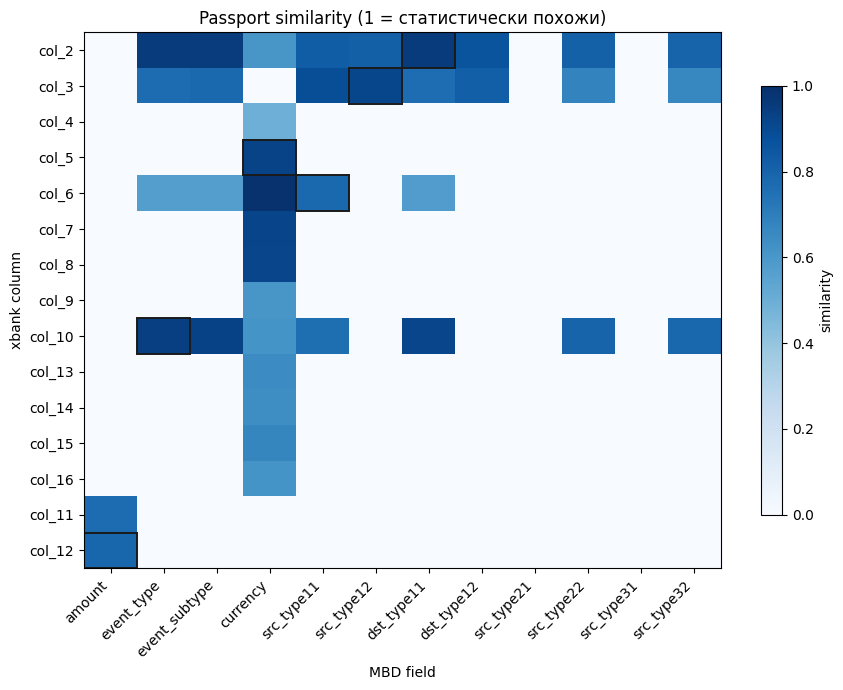

In [9]:
# матрица похожести паспортов; рамками обведены пары, выбранные матчером
import matplotlib.pyplot as plt

sim = pd.read_csv(PROFILES / 'similarity.csv', index_col='column')
frozen = json.loads((PROFILES / 'frozen_mapping.json').read_text())

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(sim.to_numpy(), cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(sim.shape[1]), sim.columns, rotation=45, ha='right')
ax.set_yticks(range(sim.shape[0]), sim.index)
ax.set_xlabel('MBD field')
ax.set_ylabel('xbank column')
ax.set_title('Passport similarity (1 = статистически похожи)')

for row, col in frozen['mapping'].items():
    if row in sim.index and col in sim.columns:
        i, j = sim.index.get_loc(row), sim.columns.get_loc(col)
        ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                   fill=False, edgecolor='#1a1a1a', lw=1.4))

fig.colorbar(im, ax=ax, label='similarity', shrink=0.8)
fig.tight_layout()
plt.show()

In [10]:
# полная таблица соответствий: строка на КАЖДУЮ колонку xbank (партнёр или явно "нет"),
# плюс незанятые слоты MBD; статусы fixed / mapped / dropped / unfilled
pd.read_csv(PROFILES / 'mapping.csv')

,xbank_col,kind,mbd_field,similarity,status
0,col_1,time,event_time,NaN,fixed
1,col_2,category,dst_type11,0.9546,mapped
2,col_3,category,src_type12,0.9106,mapped
3,col_4,category,NaN,NaN,dropped
4,col_5,category,currency,0.9237,mapped
5,col_6,category,src_type11,0.7842,mapped
6,col_7,category,NaN,NaN,dropped
7,col_8,category,NaN,NaN,dropped
8,col_9,category,NaN,NaN,dropped
9,col_10,category,event_type,0.9403,mapped


In [11]:
# ИТОГ прогона: якоря, recovery тестбедов, ключевые метаданные заморозки
display(pd.read_csv(PROFILES / 'anchors.csv'))

tb_path = PROFILES / 'testbed_recovery.csv'
if tb_path.exists():
    display(pd.read_csv(tb_path).groupby('variant')['correct'].agg(['sum', 'count']))

meta = json.loads((PROFILES / 'frozen_mapping.json').read_text())['meta']
print('created:     ', meta['created'])
print('profiled_on: ', meta['profiled_on'])
print('testbeds:    ', meta['testbed_recovery'])
print('matcher:     ', meta['matcher']['algorithm'], '| cutoff', meta['matcher']['min_sim_cutoff'])

,xbank_col,expected,why_known,auto_assigned,verdict
0,col_1,event_time,"dtype DATE, range 2022-2024 (schema.py)",event_time,OK
1,col_2,event_type,"report.html: MCC-like, 52 values (schema.py)",dst_type11,AMBIGUOUS
2,col_11,amount,one of the only two continuous columns (schema...,NaN,INFO
3,col_12,amount,the other continuous column; which-is-which un...,amount,INFO


,sum,count
variant,,
folds,12,12


created:      2026-09-18T16:04:23+00:00
profiled_on:  {'xbank': {'path': '/home/stsix/xbank-transfer/data/xbank_data/trans_any_pos_anonym_encoded.parquet', 'sample_rows': 2000000}, 'mbd': {'root': '/home/stsix/xbank-transfer/data/mbd', 'folds': [0], 'sample_rows': 2000000}}
testbeds:     {'folds': '12/12 exact (hungarian)', 'daily_folds': '12/12 exact (hungarian)', 'daily': '12/12 exact over real fields (hungarian)'}
matcher:      hungarian | cutoff 0.3


### v_2

Появляются после `python -m cross_schema.column_profiles_v2` в `/home/stsix/xbank-transfer/data/profiles_v2`.

In [12]:
import json
from pathlib import Path
import duckdb
import pandas as pd

PROFILES_v2 = Path('/home/stsix/xbank-transfer/data/profiles_v2')

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 180)
con = duckdb.connect()

In [13]:
pd.read_csv(PROFILES_v2 / 'xbank_profiles.csv')

,column,kind,n_rows,n_valid,null_share,n_unique,uniqueness,entropy_norm,top1_share,top3_share,min,max,mean,std,zero_share,q05,q25,q50,q75,q95,numeric_subtype,integer_share,quantile_scale,quantile_fallback,quantile_shape
0,col_2,categorical,2000000,2000000,0.0,52,0.000026,0.509509,0.481936,0.675083,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,col_3,categorical,2000000,2000000,0.0,135,0.000068,0.195505,0.539639,0.969638,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,col_4,categorical,2000000,2000000,0.0,2,0.000001,0.870538,0.708588,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,col_5,categorical,2000000,2000000,0.0,3,0.000002,0.005714,0.999273,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,col_6,categorical,2000000,2000000,0.0,13,0.000006,0.001804,0.999548,0.999854,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,col_7,categorical,2000000,2000000,0.0,3,0.000002,0.015384,0.997779,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,col_8,categorical,2000000,2000000,0.0,3,0.000002,0.026788,0.995663,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,col_9,categorical,2000000,2000000,0.0,4,0.000002,0.644486,0.584732,0.999557,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,col_10,categorical,2000000,2000000,0.0,27,0.000013,0.569609,0.464639,0.747992,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,col_13,categorical,2000000,2000000,0.0,6,0.000003,0.577500,0.550690,0.971425,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
pd.read_csv(PROFILES_v2 / 'mbd_profiles.csv')

,column,kind,n_rows,n_valid,null_share,n_unique,uniqueness,entropy_norm,top1_share,top3_share,min,max,mean,std,zero_share,q05,q25,q50,q75,q95,numeric_subtype,integer_share,quantile_scale,quantile_fallback,quantile_shape
0,amount,numeric,2000000,2000000,0.000000,1982723,0.991362,NaN,NaN,NaN,0.000005,3.205625e+11,1.499992e+06,2.965297e+08,0.0,84.215974,2819.874634,20875.672852,113486.285156,1299503.75,continuous,0.028206,1.299420e+06,none,"[-0.01606004951310297, -0.016000572819407203, ..."
1,event_type,categorical,2000000,2000000,0.000000,53,0.000027,0.562487,0.375430,0.619830,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,event_subtype,categorical,2000000,2000000,0.000000,60,0.000030,0.550601,0.372756,0.614851,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,currency,categorical,2000000,1999990,0.000005,11,0.000005,0.003290,0.999144,0.999887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,src_type11,categorical,2000000,1989676,0.005162,54,0.000027,0.219991,0.785263,0.933299,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,src_type12,categorical,2000000,1989676,0.005162,210,0.000105,0.310379,0.623954,0.784150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,dst_type11,categorical,2000000,1988237,0.005881,49,0.000024,0.522462,0.306597,0.652509,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,dst_type12,categorical,2000000,1988237,0.005881,209,0.000105,0.453786,0.288116,0.546952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,src_type21,categorical,2000000,1997923,0.001038,13724,0.006862,0.718939,0.101405,0.124467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,src_type22,categorical,2000000,1997923,0.001038,86,0.000043,0.798310,0.252785,0.355599,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


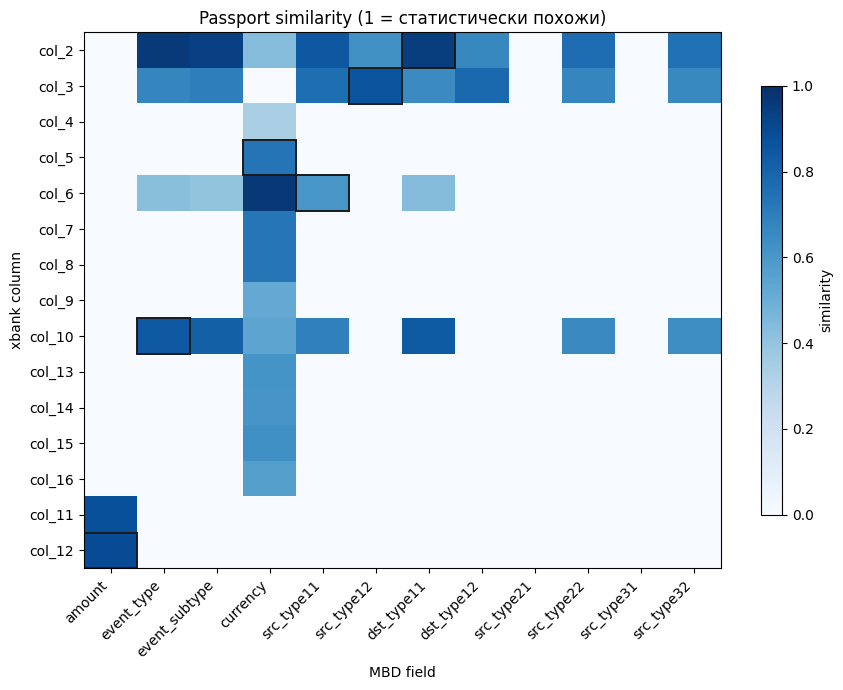

In [15]:
# матрица похожести паспортов; рамками обведены пары, выбранные матчером
import matplotlib.pyplot as plt

sim = pd.read_csv(PROFILES_v2 / 'similarity.csv', index_col='column')
frozen = json.loads((PROFILES_v2 / 'frozen_mapping.json').read_text())

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(sim.to_numpy(), cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(sim.shape[1]), sim.columns, rotation=45, ha='right')
ax.set_yticks(range(sim.shape[0]), sim.index)
ax.set_xlabel('MBD field')
ax.set_ylabel('xbank column')
ax.set_title('Passport similarity (1 = статистически похожи)')

for row, col in frozen['mapping'].items():
    if row in sim.index and col in sim.columns:
        i, j = sim.index.get_loc(row), sim.columns.get_loc(col)
        ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                   fill=False, edgecolor='#1a1a1a', lw=1.4))

fig.colorbar(im, ax=ax, label='similarity', shrink=0.8)
fig.tight_layout()
plt.show()

In [16]:
# полная таблица соответствий: строка на КАЖДУЮ колонку xbank (партнёр или явно "нет"),
# плюс незанятые слоты MBD; статусы fixed / mapped / dropped / unfilled
pd.read_csv(PROFILES_v2 / 'mapping.csv')

,xbank_col,kind,mbd_field,similarity,status
0,col_1,time,event_time,NaN,fixed
1,col_2,category,dst_type11,0.9493,mapped
2,col_3,category,src_type12,0.8584,mapped
3,col_4,category,NaN,NaN,dropped
4,col_5,category,currency,0.7359,mapped
5,col_6,category,src_type11,0.6023,mapped
6,col_7,category,NaN,NaN,dropped
7,col_8,category,NaN,NaN,dropped
8,col_9,category,NaN,NaN,dropped
9,col_10,category,event_type,0.8433,mapped


In [17]:
# ИТОГ прогона: якоря, recovery тестбедов, ключевые метаданные заморозки
display(pd.read_csv(PROFILES_v2 / 'anchors.csv'))

tb_path = PROFILES_v2 / 'testbed_recovery.csv'
if tb_path.exists():
    display(pd.read_csv(tb_path).groupby('variant')['correct'].agg(['sum', 'count']))

meta = json.loads((PROFILES_v2 / 'frozen_mapping.json').read_text())['meta']
print('created:     ', meta['created'])
print('profiled_on: ', meta['profiled_on'])
print('testbeds:    ', meta['testbed_recovery'])
print('matcher:     ', meta['matcher']['algorithm'], '| cutoff', meta['matcher']['min_sim_cutoff'])

,xbank_col,expected,why_known,auto_assigned,verdict
0,col_1,event_time,"dtype DATE, range 2022-2024 (schema.py)",event_time,OK
1,col_2,event_type,hypothesis only: MCC-like does not establish e...,dst_type11,INFO
2,col_11,amount,one of the only two continuous columns (schema...,NaN,INFO
3,col_12,amount,the other continuous column; which-is-which un...,amount,INFO


,sum,count
variant,,
daily,12,15
daily_folds,12,12
folds,12,12


created:      2026-09-23T15:15:03+00:00
profiled_on:  {'xbank': {'path': '/home/stsix/xbank-transfer/data/xbank_data/trans_any_pos_anonym_encoded.parquet', 'sample_rows': 2000000}, 'mbd': {'root': '/home/stsix/xbank-transfer/data/mbd', 'folds': [0], 'sample_rows': 2000000}}
testbeds:     {'folds': '12/12 exact (hungarian)', 'daily_folds': '12/12 exact (hungarian)', 'daily': '12/12 exact over real fields (hungarian)'}
matcher:      hungarian | cutoff 0.3


In [18]:
confidence = pd.read_csv(PROFILES_v2 / "assignment_diagnostics.csv")
correlations = json.loads(
    (PROFILES_v2 / "correlation_diagnostics.json").read_text(encoding="utf-8")
)

print("=== assignment diagnostics ===")
display(confidence)

print(f"Correlation check: {correlations['status']}")
if correlations.get("reason"):
    print(correlations["reason"])
if correlations.get("pairs"):
    display(pd.DataFrame(correlations["pairs"]))

=== assignment diagnostics ===


,xbank_col,mbd_field,similarity,row_margin,column_margin,assignment_gap,status
0,col_12,amount,0.894225,0.894225,0.016611,0.016611,AMBIGUOUS
1,col_2,dst_type11,0.949316,-0.009629,0.116739,0.001124,AMBIGUOUS
2,col_3,src_type12,0.858354,0.075604,0.230171,0.075604,SEPARATED
3,col_5,currency,0.735920,0.735920,-0.229697,0.003148,AMBIGUOUS
4,col_6,src_type11,0.602302,-0.363314,-0.241754,0.179372,SEPARATED
5,col_10,event_type,0.843329,0.010752,-0.115615,0.001124,AMBIGUOUS


Correlation check: SKIPPED
fewer than two matched numeric columns


### v_FGW

Появляются после `python -m cross_schema.column_profiles_v2` в `/home/stsix/xbank-transfer/data/profiles_vFGW`.

In [19]:
import json
from pathlib import Path
import duckdb
import pandas as pd

PROFILES_vFGW = Path('/home/stsix/xbank-transfer/data/profiles_vFGW')

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 180)
con = duckdb.connect()

In [20]:
pd.read_csv(PROFILES_vFGW / 'xbank_profiles.csv')

,column,kind,n_rows,n_valid,null_share,n_unique,uniqueness,entropy_norm,top1_share,top3_share,min,max,mean,std,zero_share,q05,q25,q50,q75,q95,numeric_subtype,integer_share,quantile_scale,quantile_fallback,quantile_shape
0,col_2,categorical,2000000,2000000,0.0,52,0.000026,0.509509,0.481936,0.675083,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,col_3,categorical,2000000,2000000,0.0,135,0.000068,0.195505,0.539639,0.969638,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,col_4,categorical,2000000,2000000,0.0,2,0.000001,0.870538,0.708588,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,col_5,categorical,2000000,2000000,0.0,3,0.000002,0.005714,0.999273,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,col_6,categorical,2000000,2000000,0.0,13,0.000006,0.001804,0.999548,0.999854,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,col_7,categorical,2000000,2000000,0.0,3,0.000002,0.015384,0.997779,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,col_8,categorical,2000000,2000000,0.0,3,0.000002,0.026788,0.995663,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,col_9,categorical,2000000,2000000,0.0,4,0.000002,0.644486,0.584732,0.999557,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,col_10,categorical,2000000,2000000,0.0,27,0.000013,0.569609,0.464639,0.747992,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,col_13,categorical,2000000,2000000,0.0,6,0.000003,0.577500,0.550690,0.971425,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
pd.read_csv(PROFILES_vFGW / 'mbd_profiles.csv')

,column,kind,n_rows,n_valid,null_share,n_unique,uniqueness,entropy_norm,top1_share,top3_share,min,max,mean,std,zero_share,q05,q25,q50,q75,q95,numeric_subtype,integer_share,quantile_scale,quantile_fallback,quantile_shape
0,amount,numeric,2000000,2000000,0.000000,1982723,0.991362,NaN,NaN,NaN,0.000005,3.205625e+11,1.499992e+06,2.965297e+08,0.0,84.215974,2819.874634,20875.672852,113486.285156,1299503.75,continuous,0.028206,1.299420e+06,none,"[-0.01606004951310297, -0.016000572819407203, ..."
1,event_type,categorical,2000000,2000000,0.000000,53,0.000027,0.562487,0.375430,0.619830,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,event_subtype,categorical,2000000,2000000,0.000000,60,0.000030,0.550601,0.372756,0.614851,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,currency,categorical,2000000,1999990,0.000005,11,0.000005,0.003290,0.999144,0.999887,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,src_type11,categorical,2000000,1989676,0.005162,54,0.000027,0.219991,0.785263,0.933299,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,src_type12,categorical,2000000,1989676,0.005162,210,0.000105,0.310379,0.623954,0.784150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,dst_type11,categorical,2000000,1988237,0.005881,49,0.000024,0.522462,0.306597,0.652509,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,dst_type12,categorical,2000000,1988237,0.005881,209,0.000105,0.453786,0.288116,0.546952,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,src_type21,categorical,2000000,1997923,0.001038,13724,0.006862,0.718939,0.101405,0.124467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,src_type22,categorical,2000000,1997923,0.001038,86,0.000043,0.798310,0.252785,0.355599,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


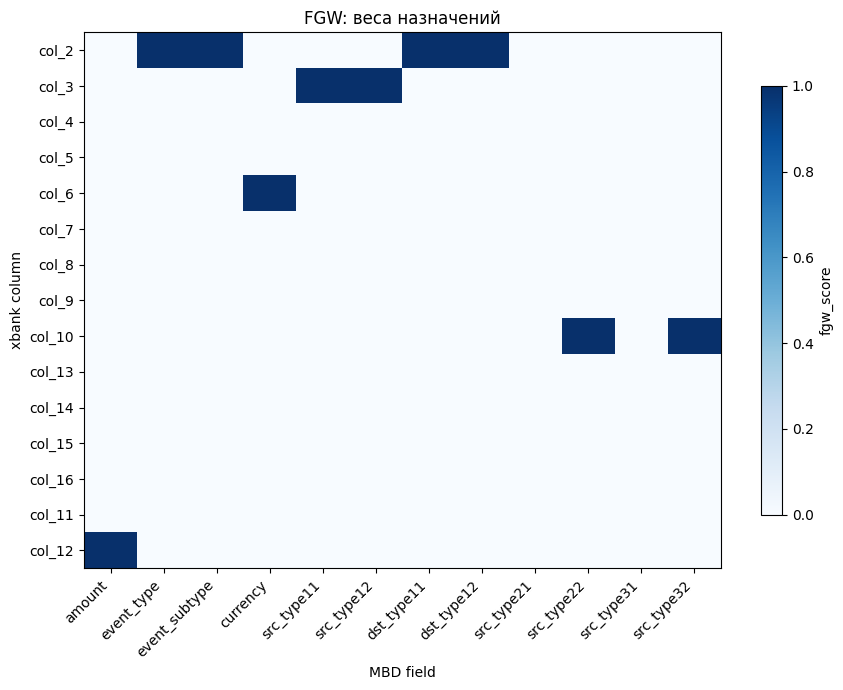

In [22]:
# матрица похожести паспортов; рамками обведены пары, выбранные матчером
import matplotlib.pyplot as plt

sim = pd.read_csv(
    PROFILES_vFGW / "fgw_scores.csv",
    index_col="column",
)
frozen = json.loads((PROFILES_vFGW / 'frozen_mapping.json').read_text())

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(sim.to_numpy(), cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(sim.shape[1]), sim.columns, rotation=45, ha='right')
ax.set_yticks(range(sim.shape[0]), sim.index)
ax.set_xlabel('MBD field')
ax.set_ylabel('xbank column')
ax.set_title("FGW: веса назначений")
fig.colorbar(im, ax=ax, label="fgw_score", shrink=0.8)

# for row, col in frozen['mapping'].items():
#     if row in sim.index and col in sim.columns:
#         i, j = sim.index.get_loc(row), sim.columns.get_loc(col)
#         ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
#                                    fill=False, edgecolor='#1a1a1a', lw=1.4))

# fig.colorbar(im, ax=ax, label='similarity', shrink=0.8)
fig.tight_layout()
plt.show()

In [23]:
# полная таблица соответствий: строка на КАЖДУЮ колонку xbank (партнёр или явно "нет"),
# плюс незанятые слоты MBD; статусы fixed / mapped / dropped / unfilled
pd.read_csv(PROFILES_vFGW / 'mapping.csv')

,mbd_field,xbank_col,status,distance,fgw_score,second_score,column_margin,candidate_count,ambiguity,source_reuse_count
0,amount,col_12,mapped,0.105775,1.0,0.0,1.0,2.0,SEPARATED,1.0
1,event_type,col_2,mapped,0.041055,1.0,0.0,1.0,4.0,SEPARATED,4.0
2,event_subtype,col_2,mapped,0.063166,1.0,0.0,1.0,4.0,SEPARATED,4.0
3,currency,col_6,mapped,0.034383,1.0,0.0,1.0,12.0,SEPARATED,1.0
4,src_type11,col_3,mapped,0.241901,1.0,0.0,1.0,4.0,SEPARATED,2.0
5,src_type12,col_3,mapped,0.141646,1.0,0.0,1.0,2.0,SEPARATED,2.0
6,dst_type11,col_2,mapped,0.050684,1.0,0.0,1.0,4.0,SEPARATED,4.0
7,dst_type12,col_2,mapped,0.338297,1.0,0.0,1.0,2.0,SEPARATED,4.0
8,src_type21,NaN,unfilled,NaN,NaN,NaN,NaN,0.0,NaN,0.0
9,src_type22,col_10,mapped,0.345933,1.0,0.0,1.0,3.0,SEPARATED,2.0


Одну колонку xbank разрешено использовать для нескольких полей MBD.

| Поле MBD | Колонка xbank | Статус | distance ↓ | fgw_score | second_score | column_margin | Кандидатов | ambiguity | Использований источника |
|---|---|---|---:|---:|---:|---:|---:|---|---:|
| amount | col_12 | mapped | 0.105775 | 1.0 | 0.0 | 1.0 | 2 | SEPARATED | 1 |
| event_type | col_2 | mapped | 0.041055 | 1.0 | 0.0 | 1.0 | 4 | SEPARATED | 4 |
| event_subtype | col_2 | mapped | 0.063166 | 1.0 | 0.0 | 1.0 | 4 | SEPARATED | 4 |
| currency | col_6 | mapped | 0.034383 | 1.0 | 0.0 | 1.0 | 12 | SEPARATED | 1 |
| src_type11 | col_3 | mapped | 0.241901 | 1.0 | 0.0 | 1.0 | 4 | SEPARATED | 2 |
| src_type12 | col_3 | mapped | 0.141646 | 1.0 | 0.0 | 1.0 | 2 | SEPARATED | 2 |
| dst_type11 | col_2 | mapped | 0.050684 | 1.0 | 0.0 | 1.0 | 4 | SEPARATED | 4 |
| dst_type12 | col_2 | mapped | 0.338297 | 1.0 | 0.0 | 1.0 | 2 | SEPARATED | 4 |
| src_type21 | — | unfilled | — | — | — | — | 0 | — | 0 |
| src_type22 | col_10 | mapped | 0.345933 | 1.0 | 0.0 | 1.0 | 3 | SEPARATED | 2 |
| src_type31 | — | unfilled | — | — | — | — | 0 | — | 0 |
| src_type32 | col_10 | mapped | 0.362506 | 1.0 | 0.0 | 1.0 | 3 | SEPARATED | 2 |

**Оптимизатор:** `CONVERGED`.  
**Результаты сохранены:** `data/profiles_vFGW`.

Сопоставлено **10 из 12 полей MBD**, использовано **5 разных колонок xbank**.
Для `src_type21` и `src_type31` допустимых кандидатов нет; при пересборке они заполняются `other_values_code` соответствующих энкодеров MBD.

`distance` — различие паспортов: меньше означает ближе.  
`fgw_score = 1` — вся масса назначения досталась одному источнику; это **не вероятность правильности**.  
`CONVERGED` означает выполнение критерия остановки оптимизатора, а не подтверждение правильности соответствий.